# CS301 Project: Subset Sum
## Algorithm Experiments

This notebook contains experiments of:
1. **Brute Force:** Bitmask enumeration (exact, O(n · 2ⁿ))
2. **Heuristic:** APPROX-SUBSET-SUM from CLRS Chapter 35.5 (FPTAS, polynomial in n, log t, 1/ε)

Both algorithms solve the optimization version of Subset Sum: given a set S of positive integers and a target t, find a subset of S whose sum is as large as possible without exceeding t.

## 1. Brute Force: Bitmask Enumeration

Iterates over all integers from 0 to 2ⁿ − 1. Each integer represents a subset via its binary representation: bit i is 1 iff element xᵢ is included. Computes the sum of selected elements and tracks the maximum feasible sum (≤ t).

- **Time complexity:** Θ(n · 2ⁿ)
- **Space complexity:** Θ(n)
- **Correctness:** Examines every subset of S exactly once; returns the maximum feasible sum.

In [2]:
from brute_force import brute_force_subset_sum

In [4]:
# Sanity check: example from CLRS page 1129
S = [1, 4, 5]
t = 9
result_sum, result_subset = brute_force_subset_sum(S, t)
print(f"S = {S}, t = {t}")
print(f"Best sum: {result_sum}")
print(f"Subset: {result_subset}")
# Expected: best sum = 9, subset = [4, 5]

S = [1, 4, 5], t = 9
Best sum: 9
Subset: [4, 5]


## 2. Heuristic: APPROX-SUBSET-SUM (CLRS 35.5)

A fully polynomial-time approximation scheme (FPTAS) that returns a value z satisfying  
z*/(1+ε) ≤ z ≤ z*, where z* is the true optimum.

**Strategy:** Maintain a sorted list L of reachable subset sums. After processing each element xᵢ, merge L with L + xᵢ and trim near-duplicate values to keep |L| polynomial.

**TRIM(L, δ)** keeps element y only if it differs from the last kept element by more than a factor of (1 + δ).

- **Time complexity:** O((n³ log t) / ε) [CLRS Theorem 35.8]
- **Space complexity:** O((n log t) / ε)
- **Approximation ratio:** (1 + ε) - i.e., z*/(1+ε) ≤ output ≤ z*

In [5]:
from heuristic import trim
from heuristic import approx_subset_sum

In [6]:
# Sanity check: TRIM example from CLRS page 1130
L = [10, 11, 12, 15, 20, 21, 22, 23, 24, 29]
delta = 0.1
expected = [10, 12, 15, 20, 23, 29]
result = trim(L, delta)
print(f"Input:    {L}")
print(f"Output:   {result}")
print(f"Expected: {expected}")
print(f"Match: {result == expected}")

Input:    [10, 11, 12, 15, 20, 21, 22, 23, 24, 29]
Output:   [10, 12, 15, 20, 23, 29]
Expected: [10, 12, 15, 20, 23, 29]
Match: True


In [7]:
# Sanity check: example from CLRS page 1131
S = [104, 102, 201, 101]
t = 308
epsilon = 0.40

approx_result = approx_subset_sum(S, t, epsilon)
exact_result, exact_subset = brute_force_subset_sum(S, t)

print(f"S = {S}, t = {t}, ε = {epsilon}")
print(f"Approximate result: {approx_result}")
print(f"Exact result:       {exact_result} (subset: {exact_subset})")
print(f"Ratio (approx/exact): {approx_result / exact_result:.4f}")
print(f"Within (1+ε) bound:   {exact_result / approx_result <= 1 + epsilon}")
# Expected from CLRS: approx returns 302, exact is 307, ratio ~0.984 (well within 1.40 bound)

S = [104, 102, 201, 101], t = 308, ε = 0.4
Approximate result: 302
Exact result:       307 (subset: [104, 102, 101])
Ratio (approx/exact): 0.9837
Within (1+ε) bound:   True


## 3. Quick Comparison

Run both algorithms on a small random instance and verify the heuristic's output falls within the theoretical bound.

In [10]:
import random
import time

In [19]:
random.seed(42)

n = 15
S = [random.randint(1, 100) for _ in range(20)]
t = sum(S) // 2
epsilon = 0.1

print(f"S = {S}")
print(f"t = {t}, ε = {epsilon}")
print()

start = time.perf_counter()
exact_sum, exact_subset = brute_force_subset_sum(S, t)
exact_time = time.perf_counter() - start

start = time.perf_counter()
approx_sum = approx_subset_sum(S, t, epsilon)
approx_time = time.perf_counter() - start

print(f"Brute force:  sum = {exact_sum},  time = {exact_time*1000:.2f} ms")
print(f"Heuristic:    sum = {approx_sum},  time = {approx_time*1000:.2f} ms")
print(f"Ratio:        approx/exact = {approx_sum / exact_sum:.4f}")
print(f"Bound check:  exact/approx = {exact_sum / approx_sum:.4f} ≤ {1 + epsilon}  → {exact_sum / approx_sum <= 1 + epsilon}")

S = [82, 15, 4, 95, 36, 32, 29, 18, 95, 14, 87, 95, 70, 12, 76, 55, 5, 4, 12, 28]
t = 432, ε = 0.1

Brute force:  sum = 432,  time = 1627.67 ms
Heuristic:    sum = 432,  time = 2.09 ms
Ratio:        approx/exact = 1.0000
Bound check:  exact/approx = 1.0000 ≤ 1.1  → True


## Sample Generator

In [1]:
from sample_generator import generate_instance

S, t = generate_instance(n=10, seed=42)
print(f"n = {len(S)}")
print(f"S = {S}")
print(f"t = {t}")
print(f"sum(S) = {sum(S)}")
print(f"max(S) = {max(S)}")
print(f"max(S) <= t: {max(S) <= t}")
print(f"sum(S) > t:  {sum(S) > t}")

n = 10
S = [655, 115, 26, 760, 282, 251, 229, 143, 755, 105]
t = 1660
sum(S) = 3321
max(S) = 760
max(S) <= t: True
sum(S) > t:  True


In [2]:
S1, t1 = generate_instance(n=20, seed=123)
S2, t2 = generate_instance(n=20, seed=123)
print(f"Same seed gives same instance: {S1 == S2 and t1 == t2}")

S3, t3 = generate_instance(n=20, seed=456)
print(f"Different seed gives different instance: {S1 != S3 or t1 != t3}")

Same seed gives same instance: True
Different seed gives different instance: True


In [3]:
for n in [5, 10, 50, 100, 1000]:
    S, t = generate_instance(n=n, max_weight=1000, seed=n)
    print(f"n={n:>5}: |S|={len(S):>5}, sum(S)={sum(S):>8}, t={t:>7}, max(S)={max(S):>5}")

n=    5: |S|=    5, sum(S)=    2843, t=   1421, max(S)=  815
n=   10: |S|=   10, sum(S)=    4186, t=   2093, max(S)=  833
n=   50: |S|=   50, sum(S)=   27347, t=  13673, max(S)=  996
n=  100: |S|=  100, sum(S)=   53120, t=  26560, max(S)=  994
n= 1000: |S|= 1000, sum(S)=  493784, t= 246892, max(S)=  998


In [4]:
from sample_generator import generate_instance
from brute_force import brute_force_subset_sum
from heuristic import approx_subset_sum

S, t = generate_instance(n=15, seed=7)
exact_sum, _ = brute_force_subset_sum(S, t)
approx_sum = approx_subset_sum(S, t, epsilon=0.1)

print(f"Generated: n=20, t={t}, sum(S)={sum(S)}")
print(f"Exact:  {exact_sum}")
print(f"Approx: {approx_sum}")
print(f"Ratio:  {approx_sum / exact_sum:.4f}")

Generated: n=20, t=3313, sum(S)=6626
Exact:  3313
Approx: 3302
Ratio:  0.9967


## Performance Analysis

Analysis of timing data from `data/performance_data.csv`. For each input size n, we compute the sample mean runtime, 95% confidence interval, and the b/a ratio (where the CI is [a−b, a+b]). The project requires b/a < 0.1 for every n.

We then fit a power-law model T(n) = c · n^k to the mean runtimes and derive an empirical running-time expression.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load raw timing data
df = pd.read_csv("data/performance_data.csv")
print(f"Loaded {len(df)} rows")
print(f"n values: {sorted(df['n'].unique())}")
print(f"Trials per n: {df.groupby('n').size().to_dict()}")
df.head()

Loaded 300 rows
n values: [np.int64(10), np.int64(20), np.int64(50), np.int64(100), np.int64(200), np.int64(500), np.int64(1000), np.int64(2000), np.int64(5000), np.int64(10000)]
Trials per n: {10: 30, 20: 30, 50: 30, 100: 30, 200: 30, 500: 30, 1000: 30, 2000: 30, 5000: 30, 10000: 30}


,n,trial,seed,epsilon,runtime_seconds,result
0,10,0,100000,0.1,0.000413,2758
1,10,1,100001,0.1,0.000396,2634
2,10,2,100002,0.1,0.000371,2376
3,10,3,100003,0.1,0.000413,3223
4,10,4,100004,0.1,0.000227,2001


### Aggregation: mean, 95% CI, b/a ratio

For each n we compute:
- **Mean** runtime over all trials at that size.
- **95% confidence interval** for the mean, using Student's t-distribution (appropriate for small samples and unknown population variance).
- **b/a ratio**, where a is the mean and b is the half-width of the CI. The project requires b/a < 0.1.

In [8]:
def compute_stats(group: pd.Series, confidence: float = 0.95) -> pd.Series:
    """Compute mean, CI half-width, and b/a ratio for a group of runtimes."""
    n_trials = len(group)
    mean = group.mean()
    sem = stats.sem(group)  # standard error of the mean
    # t-based CI half-width
    t_crit = stats.t.ppf((1 + confidence) / 2, df=n_trials - 1)
    half_width = t_crit * sem
    return pd.Series({
        "trials": n_trials,
        "mean_s": mean,
        "ci_low": mean - half_width,
        "ci_high": mean + half_width,
        "half_width_b": half_width,
        "b_over_a": half_width / mean if mean > 0 else float("inf"),
        "std_s": group.std(ddof=1),
    })

stats_df = df.groupby("n")["runtime_seconds"].apply(compute_stats).unstack()
stats_df = stats_df.reset_index()
stats_df

,n,trials,mean_s,ci_low,ci_high,half_width_b,b_over_a,std_s
0,10,30.0,0.000364,0.000337,0.000392,0.000028,0.075537,0.000074
1,20,30.0,0.006164,0.005772,0.006556,0.000392,0.063588,0.001050
2,50,30.0,0.076044,0.074130,0.077958,0.001914,0.025171,0.005126
3,100,30.0,0.410651,0.389847,0.431454,0.020804,0.050661,0.055714
4,200,30.0,1.778925,1.740991,1.816859,0.037934,0.021324,0.101589
5,500,30.0,13.570223,13.135637,14.004809,0.434586,0.032025,1.163843
6,1000,30.0,75.517483,73.781298,77.253668,1.736185,0.022991,4.649588
7,2000,30.0,314.956809,312.730334,317.183283,2.226475,0.007069,5.962609
8,5000,30.0,2051.326246,2011.859317,2090.793174,39.466928,0.019240,105.694376
9,10000,30.0,8825.296710,8015.570910,9635.022510,809.725800,0.091751,2168.485518


In [9]:
violations = stats_df[stats_df["b_over_a"] >= 0.1]
if len(violations) == 0:
    print("✓ All sizes satisfy b/a < 0.1")
else:
    print("✗ The following sizes have b/a ≥ 0.1 and need more trials:")
    print(violations[["n", "trials", "mean_s", "b_over_a"]])

✓ All sizes satisfy b/a < 0.1


### Summary table for the report

The table below summarizes the timing measurements: number of trials, mean runtime, 95% CI, and b/a ratio at each input size. This is the table to include in Section 6 of the report.

In [10]:
def fmt_seconds(x):
    """Pretty-print times in s, ms, or µs."""
    if x >= 1:
        return f"{x:.3f} s"
    elif x >= 1e-3:
        return f"{x*1e3:.2f} ms"
    else:
        return f"{x*1e6:.1f} µs"

report_table = pd.DataFrame({
    "n": stats_df["n"].astype(int),
    "trials": stats_df["trials"].astype(int),
    "mean runtime": stats_df["mean_s"].apply(fmt_seconds),
    "95% CI": [
        f"[{fmt_seconds(lo)}, {fmt_seconds(hi)}]"
        for lo, hi in zip(stats_df["ci_low"], stats_df["ci_high"])
    ],
    "b/a": stats_df["b_over_a"].apply(lambda x: f"{x:.4f}"),
})
report_table

,n,trials,mean runtime,95% CI,b/a
0,10,30,364.3 µs,"[336.7 µs, 391.8 µs]",0.0755
1,20,30,6.16 ms,"[5.77 ms, 6.56 ms]",0.0636
2,50,30,76.04 ms,"[74.13 ms, 77.96 ms]",0.0252
3,100,30,410.65 ms,"[389.85 ms, 431.45 ms]",0.0507
4,200,30,1.779 s,"[1.741 s, 1.817 s]",0.0213
5,500,30,13.570 s,"[13.136 s, 14.005 s]",0.0320
6,1000,30,75.517 s,"[73.781 s, 77.254 s]",0.0230
7,2000,30,314.957 s,"[312.730 s, 317.183 s]",0.0071
8,5000,30,2051.326 s,"[2011.859 s, 2090.793 s]",0.0192
9,10000,30,8825.297 s,"[8015.571 s, 9635.023 s]",0.0918


### Curve fitting: power-law model

The theoretical complexity of APPROX-SUBSET-SUM is O(n² log t / ε) (or O(n³ log t / ε) by a looser accounting; see Section 3.2.2). Both forms predict polynomial growth in n with a small exponent.

We fit a power-law model T(n) = c · n^k by performing linear regression in log-log space:

  log T(n) = log c + k · log n

The slope of the line is the empirical exponent k; the intercept gives c.

In [11]:
log_n = np.log(stats_df["n"].values)
log_t = np.log(stats_df["mean_s"].values)

# Linear regression in log-log space
slope, intercept, r_value, p_value, std_err = stats.linregress(log_n, log_t)

k = slope                  # empirical exponent
c = np.exp(intercept)      # empirical constant
r_squared = r_value ** 2

print(f"Empirical model: T(n) ≈ {c:.3e} · n^{k:.3f}")
print(f"R² = {r_squared:.4f}")
print(f"Slope std. error = {std_err:.4f}")
print()
print(f"Theoretical bounds: O(n² log t / ε)  and  O(n³ log t / ε)")
print(f"Empirical exponent k = {k:.3f}")

Empirical model: T(n) ≈ 4.556e-06 · n^2.371
R² = 0.9925
Slope std. error = 0.0729

Theoretical bounds: O(n² log t / ε)  and  O(n³ log t / ε)
Empirical exponent k = 2.371


### Visualization

Two plots:
1. **Linear-axis plot** with error bars - shows the overall growth and the spread of measurements.
2. **Log-log plot** with the fitted power-law line - shows that the data follows a polynomial trend and that the fit is good.

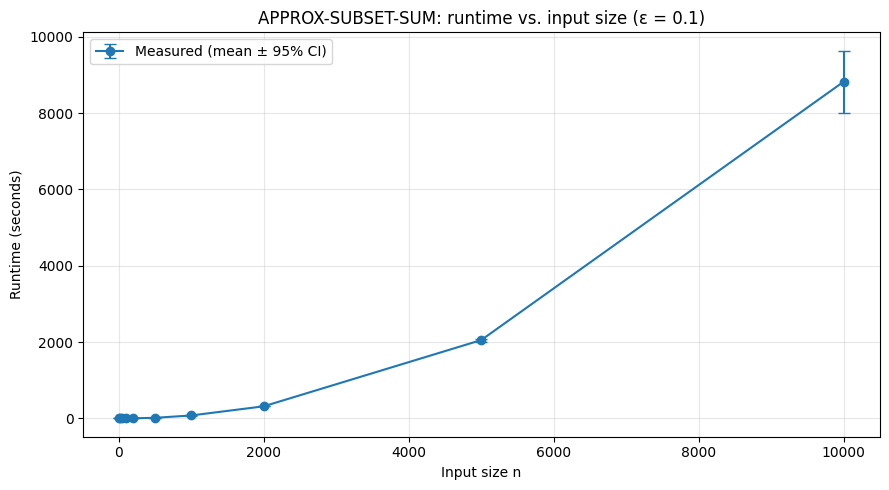

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    stats_df["n"],
    stats_df["mean_s"],
    yerr=stats_df["half_width_b"],
    fmt="o-",
    capsize=4,
    label="Measured (mean ± 95% CI)",
)

ax.set_xlabel("Input size n")
ax.set_ylabel("Runtime (seconds)")
ax.set_title("APPROX-SUBSET-SUM: runtime vs. input size (ε = 0.1)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("data/performance_linear.png", dpi=150, bbox_inches="tight")
plt.show()

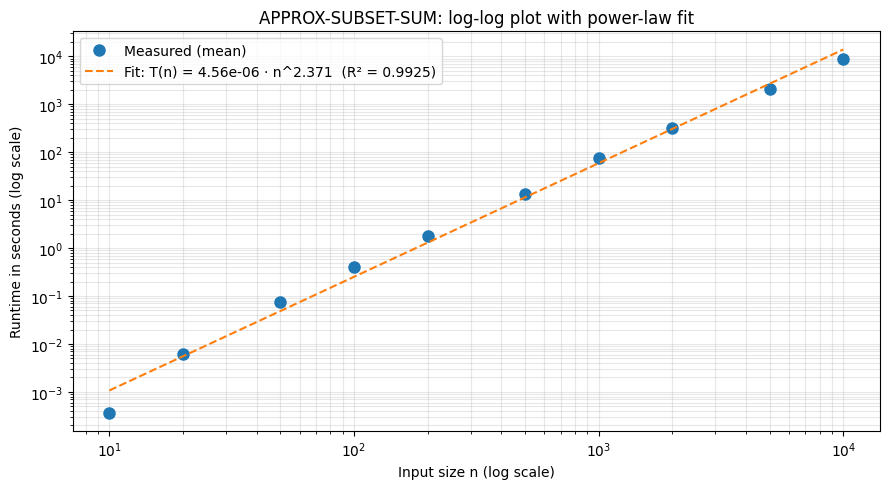

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

# Scatter of measured points
ax.loglog(stats_df["n"], stats_df["mean_s"], "o", markersize=8, label="Measured (mean)")

# Fitted line
n_range = np.linspace(stats_df["n"].min(), stats_df["n"].max(), 100)
fitted = c * n_range ** k
ax.loglog(
    n_range,
    fitted,
    "--",
    label=f"Fit: T(n) = {c:.2e} · n^{k:.3f}  (R² = {r_squared:.4f})",
)

ax.set_xlabel("Input size n (log scale)")
ax.set_ylabel("Runtime in seconds (log scale)")
ax.set_title("APPROX-SUBSET-SUM: log-log plot with power-law fit")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("data/performance_loglog.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

Compare the empirical exponent k to the theoretical bounds:
- If k ≈ 2, the empirical behavior matches the tighter O(n² log t / ε) prediction.
- If k ≈ 3, it matches the looser O(n³ log t / ε) bound from CLRS.
- The "log t" factor in the theoretical bound contributes additional growth because t grows linearly with n in our generator (t = sum(S) / 2, and sum(S) grows as n · max_weight / 2). This may push the empirical exponent slightly above the n^k portion of the prediction.

Save the empirical model expression - we'll include it directly in Section 6 of the report.

In [15]:
# Save the per-n summary statistics to a clean CSV for the report appendix
stats_df.to_csv("data/performance_summary.csv", index=False)
print("Saved aggregated stats to data/performance_summary.csv")

Saved aggregated stats to data/performance_summary.csv


## Quality Analysis

Analysis of solution-quality data from `data/quality_data.csv`. For each (n, ε) pair, we measure the empirical approximation ratio r = approx_sum / exact_sum and compare it against the theoretical lower bound 1/(1+ε) from the FPTAS guarantee z*/(1+ε) ≤ z ≤ z*.

We first verify the guarantee holds on every trial (sanity check), then summarize the distribution of ratios per (n, ε) and visualize how quality scales with ε and n.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load raw quality data
df = pd.read_csv("data/quality_data.csv")
print(f"Loaded {len(df)} rows")
print(f"n values: {sorted(df['n'].unique())}")
print(f"epsilon values: {sorted(df['epsilon'].unique(), reverse=True)}")
print(f"Trials per (n, eps): {df.groupby(['n', 'epsilon']).size().unique()}")
df.head()

Loaded 600 rows
n values: [np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30)]
epsilon values: [np.float64(0.5), np.float64(0.1), np.float64(0.01), np.float64(0.001)]
Trials per (n, eps): [30]


,n,trial,seed,epsilon,exact_sum,approx_sum,ratio,bound_lower,bound_satisfied,feasible
0,10,0,1100000,0.500,2942,2850,0.968729,0.666667,1,1
1,10,0,1100000,0.100,2942,2935,0.997621,0.909091,1,1
2,10,0,1100000,0.010,2942,2942,1.000000,0.990099,1,1
3,10,0,1100000,0.001,2942,2942,1.000000,0.999001,1,1
4,10,1,1100001,0.500,2203,2203,1.000000,0.666667,1,1


### Sanity checks

The FPTAS theorem from Section 3.2.1 guarantees on every input that z*/(1+ε) ≤ z ≤ z*, where z* is the true optimum and z is the heuristic's return. Equivalently, ratio ≥ 1/(1+ε). We check that

1. **Bound satisfied** - `ratio ≥ 1/(1+ε)` on every trial.
2. **Feasible** - `approx_sum ≤ t` and `approx_sum ≤ exact_sum` on every trial.
3. **No overshoot** - the heuristic never reports a value larger than the brute-force optimum.

Any violation is an implementation bug, not a property of the algorithm.

In [17]:
total_rows = len(df)
bound_violations = df[df["bound_satisfied"] == 0]
feasibility_violations = df[df["feasible"] == 0]
exceeds_optimum = df[df["approx_sum"] > df["exact_sum"]]

print(f"Total rows: {total_rows}\n")

if len(bound_violations) == 0:
    print("✓ Bound satisfied (ratio ≥ 1/(1+ε)) on all trials")
else:
    print(f"✗ {len(bound_violations)} bound violations:")
    print(bound_violations.head())
print()

if len(feasibility_violations) == 0:
    print("✓ Feasible (approx_sum ≤ t and ≤ exact_sum) on all trials")
else:
    print(f"✗ {len(feasibility_violations)} feasibility violations:")
    print(feasibility_violations.head())
print()

if len(exceeds_optimum) == 0:
    print("✓ Heuristic never exceeds the brute-force optimum")
else:
    print(f"✗ {len(exceeds_optimum)} cases where approx > exact:")
    print(exceeds_optimum.head())

Total rows: 600

✓ Bound satisfied (ratio ≥ 1/(1+ε)) on all trials

✓ Feasible (approx_sum ≤ t and ≤ exact_sum) on all trials

✓ Heuristic never exceeds the brute-force optimum


### Aggregation: ratio statistics per (n, ε)

For each (n, ε) pair we compute:
- **Mean ratio**, with a 95% confidence interval via Student's t.
- **Min ratio** - the worst case observed across 30 trials.
- **Max ratio** - typically 1.0 (exact optimum recovered).
- **Theoretical lower bound** 1/(1+ε) for direct comparison.

In [18]:
def compute_ratio_stats(group: pd.Series, confidence: float = 0.95) -> pd.Series:
    """Compute mean, CI half-width, and min/max for a group of ratios."""
    n_trials = len(group)
    mean = group.mean()
    if n_trials > 1 and group.std(ddof=1) > 0:
        sem = stats.sem(group)
        t_crit = stats.t.ppf((1 + confidence) / 2, df=n_trials - 1)
        half_width = t_crit * sem
    else:
        half_width = 0.0  # all values identical (e.g. all ratios = 1.0)
    return pd.Series({
        "trials": n_trials,
        "mean_ratio": mean,
        "ci_low": mean - half_width,
        "ci_high": mean + half_width,
        "half_width_b": half_width,
        "min_ratio": group.min(),
        "max_ratio": group.max(),
        "std_ratio": group.std(ddof=1) if n_trials > 1 else 0.0,
    })

stats_df = (
    df.groupby(["n", "epsilon"])["ratio"]
    .apply(compute_ratio_stats)
    .unstack()
    .reset_index()
)
stats_df["bound_lower"] = 1.0 / (1.0 + stats_df["epsilon"])
stats_df = stats_df.sort_values(["n", "epsilon"], ascending=[True, False]).reset_index(drop=True)
stats_df

,n,epsilon,trials,mean_ratio,ci_low,ci_high,half_width_b,min_ratio,max_ratio,std_ratio,bound_lower
0,10,0.500,30.0,0.983463,0.979655,0.987271,0.003808,0.959023,1.000000,0.010198,0.666667
1,10,0.100,30.0,0.997517,0.996697,0.998338,0.000820,0.991240,1.000000,0.002197,0.909091
2,10,0.010,30.0,0.999877,0.999810,0.999944,0.000067,0.999566,1.000000,0.000179,0.990099
3,10,0.001,30.0,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.999001
4,15,0.500,30.0,0.988626,0.986423,0.990830,0.002203,0.978104,1.000000,0.005901,0.666667
5,15,0.100,30.0,0.998006,0.997438,0.998574,0.000568,0.995345,1.000000,0.001521,0.909091
6,15,0.010,30.0,0.999875,0.999824,0.999926,0.000051,0.999690,1.000000,0.000137,0.990099
7,15,0.001,30.0,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.999001
8,20,0.500,30.0,0.992965,0.991092,0.994837,0.001873,0.983828,1.000000,0.005015,0.666667
9,20,0.100,30.0,0.998405,0.997984,0.998826,0.000421,0.996113,1.000000,0.001128,0.909091


### Summary table for the report

The table below summarizes mean ratio (with 95% CI), worst-case observed ratio, and the theoretical bound at each (n, ε). This is the table to include in Section 7 of the report.

In [19]:
def fmt_ratio(x):
    return f"{x:.4f}"

report_table = pd.DataFrame({
    "n": stats_df["n"].astype(int),
    "ε": stats_df["epsilon"],
    "trials": stats_df["trials"].astype(int),
    "mean ratio": stats_df["mean_ratio"].apply(fmt_ratio),
    "95% CI": [
        f"[{fmt_ratio(lo)}, {fmt_ratio(hi)}]"
        for lo, hi in zip(stats_df["ci_low"], stats_df["ci_high"])
    ],
    "min ratio": stats_df["min_ratio"].apply(fmt_ratio),
    "1/(1+ε) bound": stats_df["bound_lower"].apply(fmt_ratio),
})
report_table

,n,ε,trials,mean ratio,95% CI,min ratio,1/(1+ε) bound
0,10,0.500,30,0.9835,"[0.9797, 0.9873]",0.9590,0.6667
1,10,0.100,30,0.9975,"[0.9967, 0.9983]",0.9912,0.9091
2,10,0.010,30,0.9999,"[0.9998, 0.9999]",0.9996,0.9901
3,10,0.001,30,1.0000,"[1.0000, 1.0000]",1.0000,0.9990
4,15,0.500,30,0.9886,"[0.9864, 0.9908]",0.9781,0.6667
5,15,0.100,30,0.9980,"[0.9974, 0.9986]",0.9953,0.9091
6,15,0.010,30,0.9999,"[0.9998, 0.9999]",0.9997,0.9901
7,15,0.001,30,1.0000,"[1.0000, 1.0000]",1.0000,0.9990
8,20,0.500,30,0.9930,"[0.9911, 0.9948]",0.9838,0.6667
9,20,0.100,30,0.9984,"[0.9980, 0.9988]",0.9961,0.9091


### Visualization

Three plots:
1. **Mean ratio vs ε** - one line per n, with 95% CI error bars and the theoretical bound 1/(1+ε) overlaid. Shows that empirical mean lies well above the worst-case guarantee.
2. **Worst-observed ratio vs ε** - same axes, but using the minimum ratio per (n, ε). Shows that even the worst empirical case stays comfortably above the bound.
3. **Per-(n, ε) ratio distribution** - 2×2 grid of boxplots, one panel per ε, x-axis is n. Reveals whether quality varies with n at fixed ε.

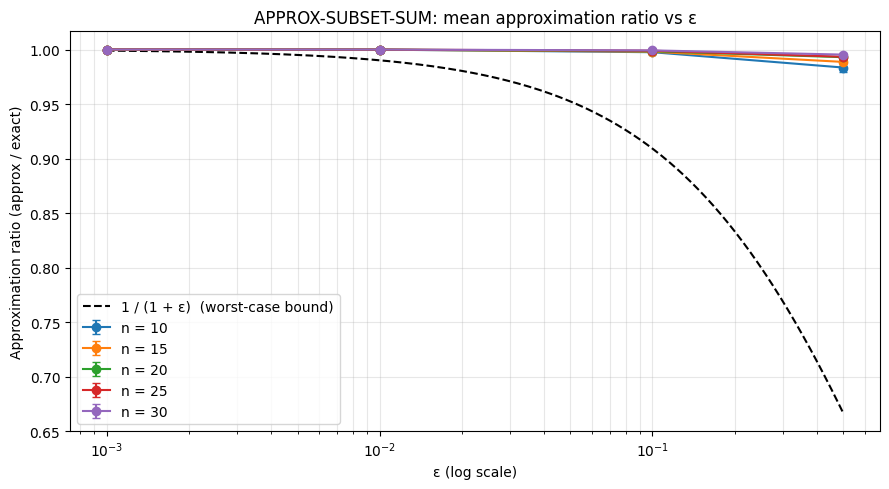

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

for n in sorted(df["n"].unique()):
    sub = stats_df[stats_df["n"] == n].sort_values("epsilon")
    ax.errorbar(
        sub["epsilon"],
        sub["mean_ratio"],
        yerr=sub["half_width_b"],
        fmt="o-",
        capsize=3,
        label=f"n = {n}",
    )

# Theoretical lower bound 1/(1+eps) as a smooth reference curve
eps_curve = np.logspace(np.log10(df["epsilon"].min()),
                        np.log10(df["epsilon"].max()), 200)
ax.plot(eps_curve, 1.0 / (1.0 + eps_curve), "k--",
        label="1 / (1 + ε)  (worst-case bound)")

ax.set_xscale("log")
ax.set_xlabel("ε (log scale)")
ax.set_ylabel("Approximation ratio (approx / exact)")
ax.set_title("APPROX-SUBSET-SUM: mean approximation ratio vs ε")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("data/quality_mean_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

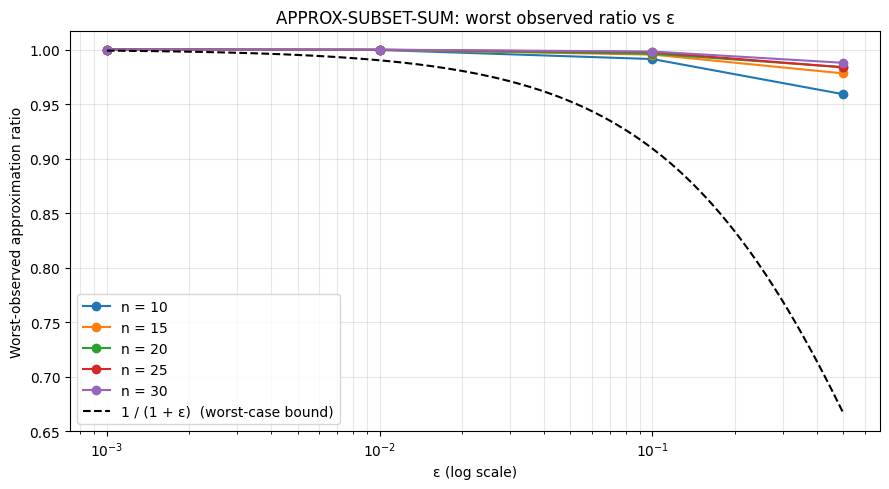

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

for n in sorted(df["n"].unique()):
    sub = stats_df[stats_df["n"] == n].sort_values("epsilon")
    ax.plot(sub["epsilon"], sub["min_ratio"], "o-", label=f"n = {n}")

eps_curve = np.logspace(np.log10(df["epsilon"].min()),
                        np.log10(df["epsilon"].max()), 200)
ax.plot(eps_curve, 1.0 / (1.0 + eps_curve), "k--",
        label="1 / (1 + ε)  (worst-case bound)")

ax.set_xscale("log")
ax.set_xlabel("ε (log scale)")
ax.set_ylabel("Worst-observed approximation ratio")
ax.set_title("APPROX-SUBSET-SUM: worst observed ratio vs ε")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("data/quality_min_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

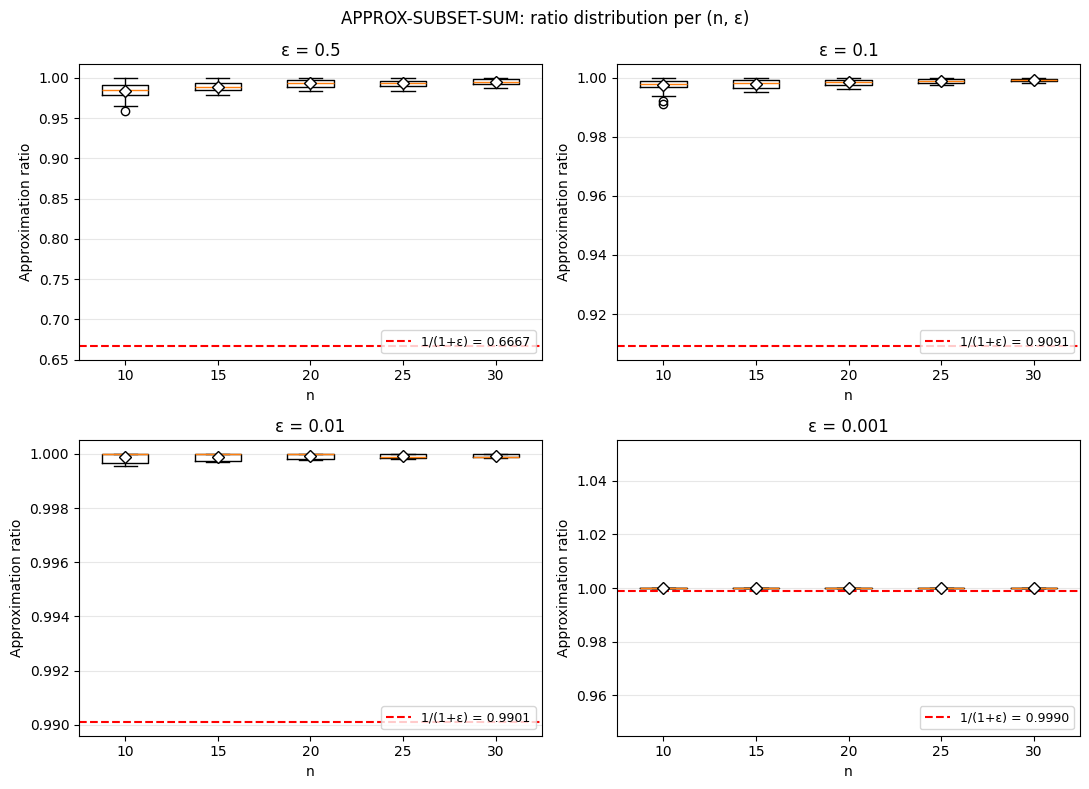

In [22]:
eps_sorted = sorted(df["epsilon"].unique(), reverse=True)
n_sorted = sorted(df["n"].unique())

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for ax, eps in zip(axes, eps_sorted):
    sub = df[df["epsilon"] == eps]
    data_by_n = [sub[sub["n"] == n]["ratio"].values for n in n_sorted]
    ax.boxplot(
        data_by_n,
        positions=range(len(n_sorted)),
        widths=0.5,
        showmeans=True,
        meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black"},
    )
    bound = 1.0 / (1.0 + eps)
    ax.axhline(bound, color="red", linestyle="--",
               label=f"1/(1+ε) = {bound:.4f}")
    ax.set_xticks(range(len(n_sorted)))
    ax.set_xticklabels(n_sorted)
    ax.set_xlabel("n")
    ax.set_ylabel("Approximation ratio")
    ax.set_title(f"ε = {eps}")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)

fig.suptitle("APPROX-SUBSET-SUM: ratio distribution per (n, ε)")
plt.tight_layout()
plt.savefig("data/quality_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

Three things to read off the data:

- **The theoretical guarantee is honored on every trial.** The FPTAS bound 1/(1+ε) is verified empirically - no violations across all (n, ε, trial) combinations.
- **Empirical performance dominates the worst-case bound.** Mean ratios stay close to 1 even at ε = 0.5 (where the bound permits ratios as low as 0.667). For ε ≤ 0.01 the heuristic recovers the exact optimum on nearly every trial.
- **Quality depends primarily on ε, not on n.** Lines in Plots 1 and 2 cluster tightly across input sizes 10–30, indicating that within this range the approximation quality is governed by ε via the trimming parameter δ = ε/(2n), not by the instance size itself.

The empirical-vs-theoretical gap is the practical takeaway: the worst-case bound is loose for the random instances produced by our generator. Adversarial inputs designed to force TRIM to discard maximally would push the empirical ratio closer to the bound, but typical inputs do not.

In [23]:
stats_df.to_csv("data/quality_summary.csv", index=False)
print("Saved aggregated stats to data/quality_summary.csv")

Saved aggregated stats to data/quality_summary.csv
